### Imports

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)

### Project setup

In [2]:
def find_project_root(marker="requirements.txt"):
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError("project root not found")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.splits import time_based_split

### Load and split

In [3]:
df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "patio_features.parquet")
train, val, test, boundaries = time_based_split(df)

print(f"Train: {len(train):,}   Val:{len(val):,}    Test:{len(test):,}")
print(f"Train period: {boundaries['data_start']} → {boundaries['train_end']}")
print(f"Val period: {boundaries['train_end']} → {boundaries['val_end']}")
print(f"Test period: {boundaries['val_end']} → {boundaries['data_end']}")

Train: 61,386   Val:13,154    Test:13,156
Train period: 2021-05-01 00:00:00 → 2024-10-30 20:54:00
Val period: 2024-10-30 20:54:00 → 2025-07-31 21:57:00
Test period: 2025-07-31 21:57:00 → 2026-05-01 23:00:00


#### Split verification

Confirm class balance is similar across splits (no temporal skew of positives) and locate Hurricane Melissa.

In [4]:
# Positive rate per split should be similar; large drift would mean a split
# landed on an anomalously wet/dry stretch.
print("Positive rate per split:")
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"  {name}: {part['wet_veranda'].mean()*100:.2f}%")

melissa_window = df[(df["time"] >= "2025-10-26") & (df["time"] <= "2025-10-31")]
print(f"\nHurricane Melissa in test set: {(melissa_window['time'] >= boundaries['val_end']).all()}")


Positive rate per split:
  train: 9.02%
  val: 9.10%
  test: 10.03%

Hurricane Melissa in test set: True


### Feature selection

The feature list is built deliberately rather than by including everything available:

**Excluded - identifiers / utility columns:** `time`, `year_month`, `latitude`, 
`longitude` (constant per location).

**Excluded - target components (would be leakage):** `precipitation` and 
`wind_gusts_10m` define the target. Including them as features at the same hour 
would be circular reasoning - the model would learn "if precip > 0.1 and gust > 15, 
predict wet_veranda" which is the target's definition, not a prediction. Their 
*lagged* values (precip_lag1, gust_lag1, etc.) are fine because those are past 
observations, not the target's components.

**Excluded - redundant per EDA:** `weather_code` (only a coarsened categorical 
version of precipitation).

**Excluded - circular variable not engineered:** `wind_direction_10m` (degrees 
0-360 - needs sin/cos engineering to be useful; deferred).

**Included - current-hour atmospheric state:** temperature, humidity, dew point, 
apparent temperature, both pressures, all four cloud-cover levels, wind speed, 
ET₀, VPD, sunshine duration. These are correlated with rain but not derived from 
the target.

**Included - ENSO context:** `oni`, `enso_phase` (one-hot encoded).

**Included - temporal:** raw `hour`, `month` plus cyclical encodings.

**Included - spatial:** `location` (one-hot encoded).

**Included - all 10 lag/trend features** built in feature engineering.

**Prediction setup:** This is **same-hour classification** - given the atmospheric 
state at hour T, predict whether wet_veranda holds at T. A forecasting setup 
(predict T+1 from features at T) is a natural extension once the baseline works.

In [5]:
NUMERIC_FEATURES = [
    # Current-hour atmospheric state
    "temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature",
    "pressure_msl", "surface_pressure",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "wind_speed_10m",
    "et0_fao_evapotranspiration", "vapour_pressure_deficit", "sunshine_duration",

    # ENSO
    "oni",

    # Temporal (raw + cyclical)
    "hour", "month", "hour_sin", "hour_cos", "month_sin", "month_cos",
    
    # Lag / trend features (built in feature engineering)
    "precip_lag1", "precip_lag3", "precip_sum_3h",
    "gust_lag1", "gust_max_3h",
    "pressure_msl_trend_3h", "pressure_msl_trend_6h",
    "cloud_cover_low_lag1",
    "humidity_lag1", "humidity_lag3",
]

CATEGORICAL_FEATURES = ["location", "enso_phase"]
TARGET = "wet_veranda"

In [6]:
def prepare_xy(df_split, fit_columns=None):
    """
    Build feature matrix X and target vector y for a split.
    
    One-hot encodes categoricals. If fit_columns is provided (from training set),
    aligns to those columns so train/val/test have identical schemas.
    Drops rows with NaN values introduced by lag features at series boundaries.
    """

    X = df_split[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
    y = df_split[TARGET].copy()

    # One-hot encode categoricals
    X = pd.get_dummies(X, columns=CATEGORICAL_FEATURES, drop_first=False)

    # Align column schema to training set
    if fit_columns is not None:
        # Add any missing dummy columns as zeros, drop any extras
        for col in fit_columns:
            if col not in X.columns:
                X[col] = 0
        X = X[fit_columns]

    # Drop rows with NaN (lag features at series boundaries - small loss, clean comparison)
    mask = ~X.isna().any(axis=1)
    return X[mask], y[mask]

X_train, y_train, = prepare_xy(train)
X_val, y_val = prepare_xy(val, fit_columns=X_train.columns)

print(f"X_train shape: {X_train.shape}  positive rate: {y_train.mean() * 100:.2f}%")
print(f"X_val shape: {X_val.shape}  positive rate:  {y_val.mean() * 100:.2f}%")
print(f"\nFeature count: {len(X_train.columns)}")
print(f"Feature columns: {list(X_train.columns)}")

X_train shape: (61374, 36)  positive rate: 9.02%
X_val shape: (13154, 36)  positive rate:  9.10%

Feature count: 36
Feature columns: ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_speed_10m', 'et0_fao_evapotranspiration', 'vapour_pressure_deficit', 'sunshine_duration', 'oni', 'hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'precip_lag1', 'precip_lag3', 'precip_sum_3h', 'gust_lag1', 'gust_max_3h', 'pressure_msl_trend_3h', 'pressure_msl_trend_6h', 'cloud_cover_low_lag1', 'humidity_lag1', 'humidity_lag3', 'location_kingston', 'location_montego_bay', 'enso_phase_el_nino', 'enso_phase_la_nina', 'enso_phase_neutral']


### Logistic Regression Sub-Baseline

In [7]:
# Scale features - LR coefficients are sentitive to feature magnitude
scaler = StandardScaler()
X_trained_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)  # use train's mean/std on val

# Train LR with balanced class weights (since 9% positive class)
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
lr.fit(X_trained_scaled, y_train)

# Predict - both class labels (0/1) and probabilities
y_train_pred = lr.predict(X_trained_scaled)
y_train_proba = lr.predict_proba(X_trained_scaled)[:, 1]
y_val_pred = lr.predict(X_val_scaled)
y_val_proba = lr.predict_proba(X_val_scaled)[:, 1]

### Evaluate the LR Baseline

In [8]:
def evaluate(y_true, y_pred, y_proba, name):
    print(f"\n --- {name} ---")
    print(classification_report(y_true, y_pred, target_names=["dry", "wet"], digits=3))
    print(f"ROC-AUC: {roc_auc_score(y_true, y_proba):.3f}")
    print(f"PR-AUC (avg precision): {average_precision_score(y_true, y_proba):.3f}")
    print(f"Confusion matrix:\n{confusion_matrix(y_true, y_pred)}")

evaluate(y_train, y_train_pred, y_train_proba, "LR on TRAIN")
evaluate(y_val, y_val_pred, y_val_proba, "LR on VAL")


 --- LR on TRAIN ---
              precision    recall  f1-score   support

         dry      0.987     0.870     0.925     55837
         wet      0.402     0.882     0.553      5537

    accuracy                          0.871     61374
   macro avg      0.695     0.876     0.739     61374
weighted avg      0.934     0.871     0.891     61374

ROC-AUC: 0.945
PR-AUC (avg precision): 0.650
Confusion matrix:
[[48581  7256]
 [  651  4886]]

 --- LR on VAL ---
              precision    recall  f1-score   support

         dry      0.981     0.892     0.934     11957
         wet      0.434     0.828     0.570      1197

    accuracy                          0.886     13154
   macro avg      0.708     0.860     0.752     13154
weighted avg      0.931     0.886     0.901     13154

ROC-AUC: 0.942
PR-AUC (avg precision): 0.628
Confusion matrix:
[[10666  1291]
 [  206   991]]


### Reading the metrics

With ~9% positive class, **accuracy is misleading** — a model that always predicts 
"dry" achieves 91% accuracy while being useless. The metrics that matter:

- **PR-AUC (average precision)** is the most informative single number for 
  imbalanced classification. It summarizes how well the model ranks positive 
  cases above negatives, weighted toward the positive class. A useless model 
  scores ~0.09 (the positive rate); 1.0 is perfect.
- **ROC-AUC** measures ranking quality but is less sensitive to imbalance — 
  a model can have high ROC-AUC and still be poor at finding the rare positives. 
  Useful but secondary here.
- **Precision** of the "wet" class = of the hours we predicted wet, how many 
  actually were. **Recall** = of the actual wet hours, how many we caught.
- **F1** for the "wet" class balances precision and recall.

For deployment, recall matters most (missing a wet-veranda event is worse than 
a false alarm), so we'll look at the recall column for the "wet" class.

### PR curve visualization

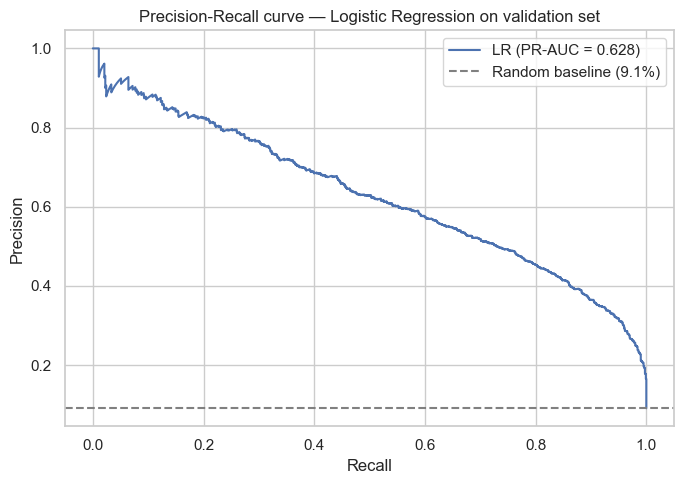

In [9]:
prec, rec, thresh = precision_recall_curve(y_val, y_val_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, label=f"LR (PR-AUC = {average_precision_score(y_val, y_val_proba):.3f})")
ax.axhline(y_val.mean(), color="gray", linestyle="--", 
           label=f"Random baseline ({y_val.mean()*100:.1f}%)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve — Logistic Regression on validation set")
ax.legend()
plt.tight_layout()

### Lag Feature Ablation

In [10]:
# Ablation: LR without lag/trend features
LAG_FEATURE_NAMES = [
    "precip_lag1", "precip_lag3", "precip_sum_3h",
    "gust_lag1", "gust_max_3h",
    "pressure_msl_trend_3h", "pressure_msl_trend_6h",
    "cloud_cover_low_lag1",
    "humidity_lag1", "humidity_lag3",
]
NO_LAG_NUMERIC = [f for f in NUMERIC_FEATURES if f not in LAG_FEATURE_NAMES]

def prepare_xy_subset(df_split, numeric_cols, fit_columns=None):
    X = df_split[numeric_cols + CATEGORICAL_FEATURES].copy()
    y = df_split[TARGET].copy()
    X = pd.get_dummies(X, columns=CATEGORICAL_FEATURES, drop_first=False)
    if fit_columns is not None:
        for col in fit_columns:
            if col not in X.columns:
                X[col] = 0
        X = X[fit_columns]
    mask = ~X.isna().any(axis=1)
    return X[mask], y[mask]

X_train_nolag, y_train_nolag = prepare_xy_subset(train, NO_LAG_NUMERIC)
X_val_nolag,   y_val_nolag   = prepare_xy_subset(val, NO_LAG_NUMERIC, fit_columns=X_train_nolag.columns)

scaler_nolag = StandardScaler()
X_train_nolag_scaled = scaler_nolag.fit_transform(X_train_nolag)
X_val_nolag_scaled = scaler_nolag.transform(X_val_nolag)

lr_nolag = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_nolag.fit(X_train_nolag_scaled, y_train_nolag)
y_val_nolag_proba = lr_nolag.predict_proba(X_val_nolag_scaled)[:, 1]

print(f"LR with lag features:    PR-AUC = {average_precision_score(y_val, y_val_proba):.3f}")
print(f"LR without lag features: PR-AUC = {average_precision_score(y_val_nolag, y_val_nolag_proba):.3f}")

LR with lag features:    PR-AUC = 0.628
LR without lag features: PR-AUC = 0.564


### XGBoost Baseline

In [11]:
import xgboost as xgb

# XGBoost handles NaN natively — we can either use the same NaN-dropped data
# as LR (for a clean comparison) or keep all rows including the lag-boundary
# NaNs. Start with the same data for a fair comparison.

# Class imbalance via scale_pos_weight ≈ ratio of negatives to positives
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",  # PR-AUC during training
    early_stopping_rounds=30, # stop if val PR-AUC doesn't improve for 30 rounds
    random_state=42,
    n_jobs=-1,
)

# No scaling needed — trees are scale-invariant
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=20,  # print progress every 20 rounds
)

y_train_pred_xgb = xgb_model.predict(X_train)
y_train_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

evaluate(y_train, y_train_pred_xgb, y_train_proba_xgb, "XGBoost on TRAIN")
evaluate(y_val,   y_val_pred_xgb,   y_val_proba_xgb,   "XGBoost on VAL")

scale_pos_weight: 10.08
[0]	validation_0-aucpr:0.63957	validation_1-aucpr:0.62193
[20]	validation_0-aucpr:0.75751	validation_1-aucpr:0.68096
[40]	validation_0-aucpr:0.79167	validation_1-aucpr:0.70612
[60]	validation_0-aucpr:0.81800	validation_1-aucpr:0.71128
[80]	validation_0-aucpr:0.84106	validation_1-aucpr:0.71791
[100]	validation_0-aucpr:0.85510	validation_1-aucpr:0.71943
[120]	validation_0-aucpr:0.87091	validation_1-aucpr:0.72047
[140]	validation_0-aucpr:0.88525	validation_1-aucpr:0.72224
[160]	validation_0-aucpr:0.89400	validation_1-aucpr:0.72037
[174]	validation_0-aucpr:0.89941	validation_1-aucpr:0.72082

 --- XGBoost on TRAIN ---
              precision    recall  f1-score   support

         dry      0.998     0.922     0.959     55837
         wet      0.555     0.984     0.710      5537

    accuracy                          0.927     61374
   macro avg      0.777     0.953     0.834     61374
weighted avg      0.958     0.927     0.936     61374

ROC-AUC: 0.988
PR-AUC (avg p

                   feature  importance
               precip_lag1    0.425492
           cloud_cover_mid    0.096282
             precip_sum_3h    0.045737
           cloud_cover_low    0.036869
                  hour_cos    0.032893
               cloud_cover    0.031416
et0_fao_evapotranspiration    0.029971
         sunshine_duration    0.026763
         location_kingston    0.024854
                      hour    0.021148
              dew_point_2m    0.015982
      relative_humidity_2m    0.014760
          cloud_cover_high    0.014484
      apparent_temperature    0.013807
                 gust_lag1    0.013185
            wind_speed_10m    0.012109
   vapour_pressure_deficit    0.011412
      cloud_cover_low_lag1    0.011384
                 month_cos    0.010711
            temperature_2m    0.010293


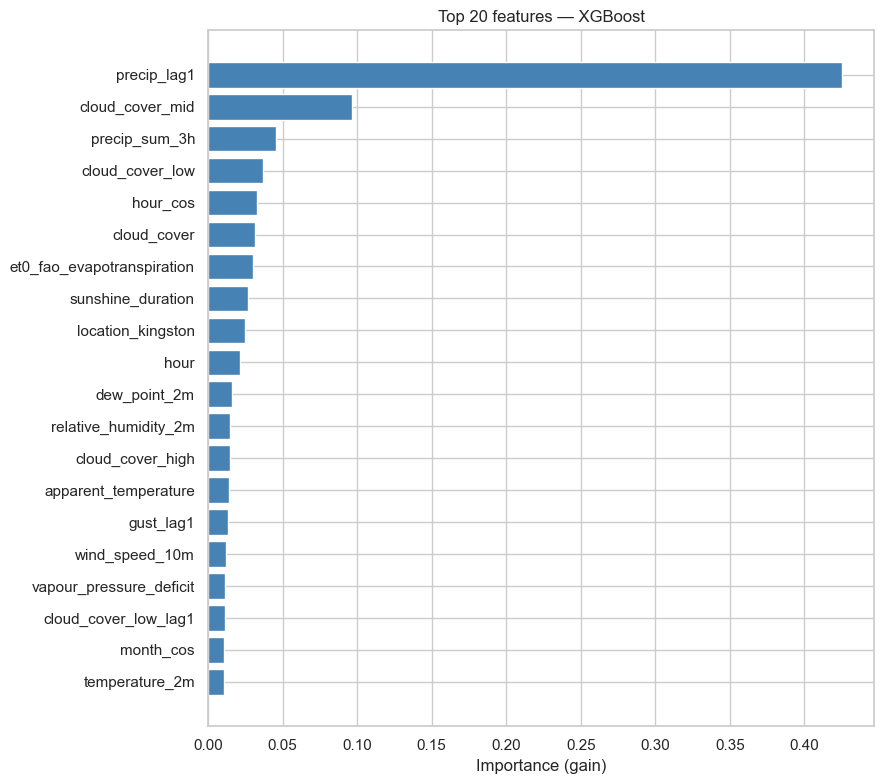

In [12]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top = importance.head(20)
ax.barh(top["feature"][::-1], top["importance"][::-1], color="steelblue")
ax.set_xlabel("Importance (gain)")
ax.set_title("Top 20 features — XGBoost")
plt.tight_layout()

print(top.to_string(index=False))

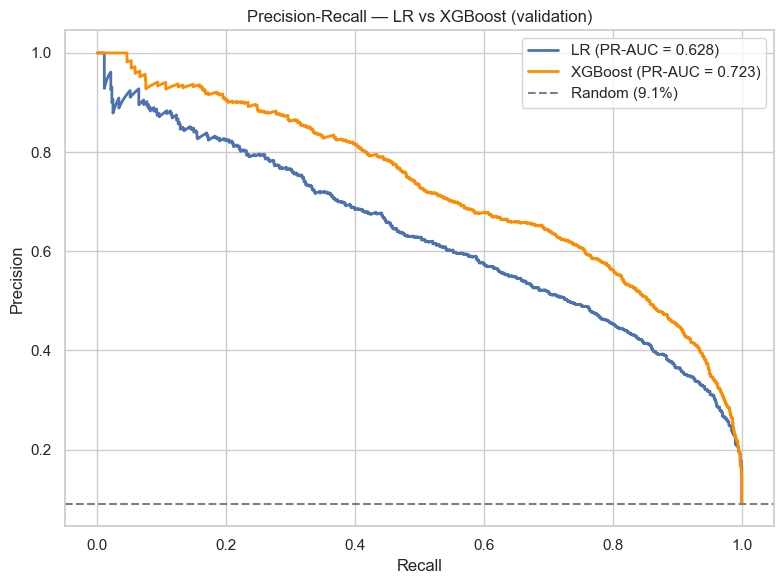

In [13]:
prec_lr, rec_lr, _ = precision_recall_curve(y_val, y_val_proba)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_val, y_val_proba_xgb)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_lr, prec_lr, label=f"LR (PR-AUC = {average_precision_score(y_val, y_val_proba):.3f})", linewidth=2)
ax.plot(rec_xgb, prec_xgb, label=f"XGBoost (PR-AUC = {average_precision_score(y_val, y_val_proba_xgb):.3f})", 
        linewidth=2, color="darkorange")
ax.axhline(y_val.mean(), color="gray", linestyle="--", label=f"Random ({y_val.mean()*100:.1f}%)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall — LR vs XGBoost (validation)")
ax.legend()
plt.tight_layout()

## Feature value investigations

Having trained the baseline, we interrogate *which* features earn their place and *how much* they add. Two investigations: (1) the pressure-trend features, which were absent from the top of the importance ranking, and (2) a persistence-only reference that quantifies the value of feature engineering beyond trivial weather inertia.

### Pressure-trend investigation

Pressure tendency is a classical storm precursor, yet `pressure_msl_trend_3h/6h` did not appear in the top-20 feature importances. Three diagnostics test whether they carry usable signal: is the tropical pressure tide present (which would confound the raw trend), does falling pressure actually precede wet hours, and does removing the features change the model?

#### Diagnostic 1 - Is the tide there?

Peak-to-trough swing across the day: 2.82 hPa
Highest at hour 10:00, lowest at hour 16:00


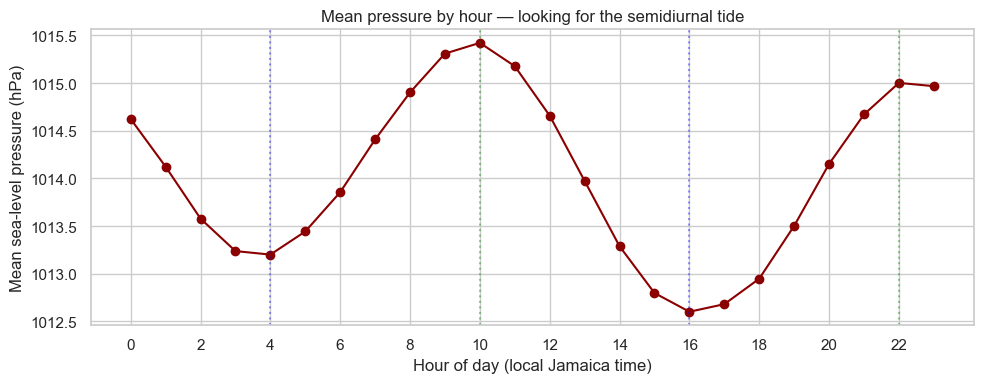

In [14]:
hourly_pressure = df.groupby(df['time'].dt.hour)['pressure_msl'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_pressure.index, hourly_pressure.values, marker='o', color='darkred')
ax.set_xlabel('Hour of day (local Jamaica time)')
ax.set_ylabel('Mean sea-level pressure (hPa)')
ax.set_title('Mean pressure by hour — looking for the semidiurnal tide')
ax.set_xticks(range(0, 24, 2))
# Expected tide peaks (~10am, ~10pm) and troughs (~4am, ~4pm)
for h in [10, 22]:
    ax.axvline(h, color='green', linestyle=':', alpha=0.4)
for h in [4, 16]:
    ax.axvline(h, color='blue', linestyle=':', alpha=0.4)
plt.tight_layout()

swing = hourly_pressure.max() - hourly_pressure.min()
print(f"Peak-to-trough swing across the day: {swing:.2f} hPa")
print(f"Highest at hour {hourly_pressure.idxmax()}:00, lowest at hour {hourly_pressure.idxmin()}:00")

#### Diagnostic 2 - Does falling pressure precede wet hours?

In [15]:
comparison = df.groupby('wet_veranda')[['pressure_msl_trend_3h', 'pressure_msl_trend_6h']].agg(['mean', 'median', 'std'])
print("Pressure trends by wet_veranda status:\n")
display(comparison.round(3))

print("\nDifference (wet minus dry):")
for trend in ['pressure_msl_trend_3h', 'pressure_msl_trend_6h']:
    wet = df[df['wet_veranda'] == 1][trend]
    dry = df[df['wet_veranda'] == 0][trend]
    print(f"  {trend}: mean {wet.mean()-dry.mean():+.3f} hPa, median {wet.median()-dry.median():+.3f} hPa")

Pressure trends by wet_veranda status:



pressure_msl_trend_3h               pressure_msl_trend_6h         \
                             mean median    std                  mean median   
wet_veranda                                                                    
0                           0.063    0.2  1.260                 0.056    0.1   
1                          -0.620   -0.8  1.296                -0.561   -0.8   

                    
               std  
wet_veranda         
0            1.789  
1            1.921


Difference (wet minus dry):
  pressure_msl_trend_3h: mean -0.683 hPa, median -1.000 hPa
  pressure_msl_trend_6h: mean -0.617 hPa, median -0.900 hPa


#### Diagnostic 3 - Ablation: do they change the model at all?

In [16]:
import xgboost as xgb
from sklearn.metrics import average_precision_score
from src.data.splits import time_based_split
from src.models.baseline import prepare_xy

train, val, test, _ = time_based_split(df)
X_train, y_train = prepare_xy(train)
X_val, y_val = prepare_xy(val, fit_columns=X_train.columns)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def train_quick(Xtr, ytr, Xva, yva):
    m = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        early_stopping_rounds=30, random_state=42, n_jobs=-1,
    )
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return m

# Full model
m_full = train_quick(X_train, y_train, X_val, y_val)
pr_full = average_precision_score(y_val, m_full.predict_proba(X_val)[:, 1])

# Without the two pressure-trend features (same rows, fewer columns)
PRESSURE_TRENDS = ['pressure_msl_trend_3h', 'pressure_msl_trend_6h']
X_train_np = X_train.drop(columns=PRESSURE_TRENDS)
X_val_np = X_val.drop(columns=PRESSURE_TRENDS)
m_np = train_quick(X_train_np, y_train, X_val_np, y_val)
pr_np = average_precision_score(y_val, m_np.predict_proba(X_val_np)[:, 1])

print(f"Full XGBoost (with pressure trends): PR-AUC = {pr_full:.4f}")
print(f"Without pressure trends:             PR-AUC = {pr_np:.4f}")
print(f"Contribution of pressure trends:     {pr_full - pr_np:+.4f}")

Full XGBoost (with pressure trends): PR-AUC = 0.7226
Without pressure trends:             PR-AUC = 0.7190
Contribution of pressure trends:     +0.0036


Pressure tendency is a classical storm precursor, and the data confirms it: wet-veranda hours showed a median pressure fall of ~0.8 hPa over the preceding 3-6 hours, versus a slight rise in dry hours. However, an ablation showed the pressure-trend features contributed negligibly to model performance (ΔPR-AUC = +0.004). This is because the signal is largely redundant with the precipitation-lag features — falling pressure and recent rainfall are correlated symptoms of the same weather systems, and the model relies on the more direct precipitation signal. Additionally, the raw trend is partly confounded by the tropical semidiurnal pressure tide (a ~2.8 hPa daily oscillation, clearly visible in the data), which masks the ~1 hPa weather signal. The features were retained as low-cost, low-harm inputs.

### Persistence reference experiment

To quantify feature-engineering value beyond trivial weather persistence, we train an XGBoost on only `precip_lag1` (previous hour's precipitation) and compare to the full feature set.

In [17]:
import xgboost as xgb
from sklearn.metrics import average_precision_score, precision_recall_curve
from src.data.splits import time_based_split
from src.models.baseline import prepare_xy

# Self-contained setup
df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "patio_features.parquet")
train, val, test, _ = time_based_split(df)
X_train, y_train = prepare_xy(train)
X_val, y_val = prepare_xy(val, fit_columns=X_train.columns)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def train_xgb(Xtr, ytr, Xva, yva, max_depth=6):
    m = xgb.XGBClassifier(
        n_estimators=500, max_depth=max_depth, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        early_stopping_rounds=30, random_state=42, n_jobs=-1,
    )
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return m

# Full model — all features
m_full = train_xgb(X_train, y_train, X_val, y_val)
proba_full = m_full.predict_proba(X_val)[:, 1]
pr_full = average_precision_score(y_val, proba_full)

# Persistence only — precip_lag1 alone (shallow; just one feature to split on)
m_persist = train_xgb(X_train[['precip_lag1']], y_train,
                      X_val[['precip_lag1']], y_val, max_depth=4)
proba_persist = m_persist.predict_proba(X_val[['precip_lag1']])[:, 1]
pr_persist = average_precision_score(y_val, proba_persist)

pr_random = y_val.mean()

print(f"Random baseline:                            PR-AUC = {pr_random:.4f}")
print(f"Persistence only (precip_lag1):             PR-AUC = {pr_persist:.4f}")
print(f"Full XGBoost (all 32 features):             PR-AUC = {pr_full:.4f}")
print()
print(f"Persistence lift over random:               +{pr_persist - pr_random:.4f}")
print(f"Feature-engineering lift over persistence:  +{pr_full - pr_persist:.4f}")
print(f"Persistence captures {pr_persist/pr_full*100:.0f}% of the full model's PR-AUC")

Random baseline:                            PR-AUC = 0.0910
Persistence only (precip_lag1):             PR-AUC = 0.4587
Full XGBoost (all 32 features):             PR-AUC = 0.7226

Persistence lift over random:               +0.3677
Feature-engineering lift over persistence:  +0.2639
Persistence captures 63% of the full model's PR-AUC


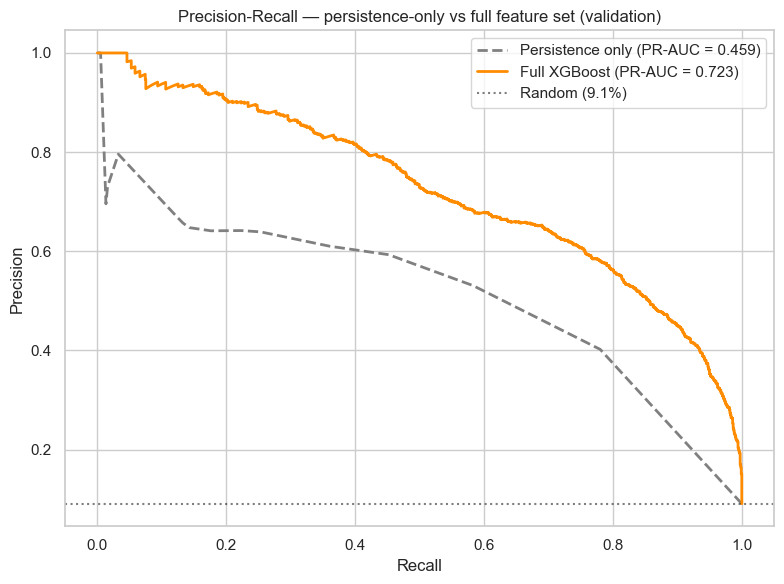

In [18]:
prec_p, rec_p, _ = precision_recall_curve(y_val, proba_persist)
prec_f, rec_f, _ = precision_recall_curve(y_val, proba_full)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_p, prec_p, label=f"Persistence only (PR-AUC = {pr_persist:.3f})",
        color="gray", linestyle="--", linewidth=2)
ax.plot(rec_f, prec_f, label=f"Full XGBoost (PR-AUC = {pr_full:.3f})",
        color="darkorange", linewidth=2)
ax.axhline(pr_random, color="black", linestyle=":", alpha=0.5,
           label=f"Random ({pr_random*100:.1f}%)")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall — persistence-only vs full feature set (validation)")
ax.legend()
plt.tight_layout()

**Findings and decision**

To quantify feature-engineering value beyond trivial weather persistence, an
XGBoost trained on only `precip_lag1` (previous hour's precipitation) was compared
to the full 32-feature model on the validation set.

| Model | Features | Val PR-AUC | Lift over random floor |
|---|---|---|---|
| Random baseline | — | 0.091 | — |
| Persistence only | precip_lag1 | 0.459 | +0.368 (58% of total) |
| Full XGBoost | all 32 | 0.723 | +0.632 (100%) |

Persistence accounts for ~58% of the achievable lift over the random floor; the
engineered atmospheric, temporal, spatial, and climate features account for the
remaining ~42%. The precision-recall curves show persistence-only achieves good
precision only at low recall (ongoing-rain cases) and degrades sharply as recall
rises, while the full model holds high precision throughout. Interpretation:
persistence predicts the continuation of existing rain; the engineered features
allow anticipation of rain onset — events that are not continuations of the prior
hour. This is the quantified justification for the feature-engineering investment.

## Baseline summary

The tabular baseline is a **nowcasting** model: given the current atmospheric state plus recent history, it classifies whether the current hour is a wet-veranda event.

- **XGBoost (val PR-AUC 0.723)** beats the logistic-regression sub-baseline (0.628) at every operating point; both far exceed the random floor (0.091).
- **Feature importance** is led by `precip_lag1` (~42% gain) — the strong hour-to-hour persistence of weather — followed by cloud cover, the daily cycle, and location.
- **Persistence reference:** a model using only `precip_lag1` reaches PR-AUC 0.459, capturing ~58% of the achievable lift over the random floor; the engineered atmospheric/temporal/spatial/climate features supply the remaining ~42%. The PR analysis localises that added value at higher recall — the engineered features let the model anticipate rain *onset*, not merely detect *continuation*.
- **Pressure trends:** genuinely present in the data (wet hours show a median ~0.8 hPa fall) but contribute negligibly to the model (ablation ΔPR-AUC ≈ +0.004), being redundant with the precipitation lags and partly confounded by the tropical semidiurnal pressure tide.

So the model is **anchored on persistence but substantially more than a persistence model.** A natural extension is a true forecasting setup — predicting `wet_veranda` at T+1 from features at T — which would weaken persistence and force greater reliance on the anticipatory features (and is where a de-tided pressure trend might finally earn its place).